<a href="https://colab.research.google.com/github/rayyang262/Badminton_ai/blob/main/BadmintonAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Badminton Movement Art — Fluid Ink Visualization

**Course:** Shared Mind — Dan O'Sullivan
**Student:** Ray Yang
**Date:** April 2026

## What This Is

This notebook takes a video of a doubles badminton match, tracks my body using pose estimation (YOLOv8-Pose), and transforms my movement into an abstract fluid ink animation. No skeleton is visible — only the physics of ink reacting to where and how fast I move across the court.

## How It Works

1. **Pose Estimation** — YOLOv8-Pose detects all players and assigns tracking IDs across frames
2. **Player Isolation** — Filters to only me (near-camera, right-side player) by analyzing bounding box size and position
3. **Court Coverage Map** — Plots a heatmap of my movement onto a scaled badminton court diagram
4. **Fluid Simulation** — Each of my 17 skeleton keypoints becomes an invisible brush pushing ink through a velocity field. Movement speed maps to color (dark green → emerald → gold → white-hot). Fast limbs create swirling currents. Explosive movements trigger screen-wide flashes.

## Why Notebooks Over APIs

No API offers "track a specific badminton player and turn their movement into a fluid painting." This required going below the API layer — loading a pose model directly, writing custom tracking filters, and building a frame-by-frame physics simulation. This is the difference between ML user and ML researcher that the assignment describes.

## Files Produced

- `badminton_coverage.png` — court coverage heatmap
- `my_movement.mp4` — annotated video (skeleton overlay, just me)
- `movement_art.mp4` — abstract fluid ink animation

## Dependencies

- `ultralytics` (YOLOv8-Pose)
- `opencv-python-headless`
- `numpy`, `matplotlib`
- Google Colab with T4 GPU

In [ ]:
!pip install ultralytics opencv-python-headless


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.2 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n-pose.pt')

results = model.track(
    source='/content/YOUR_VIDEO.mp4',
    show=False,
    save=True,
    stream=True,
    tracker='bytetrack.yaml'
)

all_frames = []
for r in results:
    all_frames.append(r)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 237ms
Prepared 1 package in 62ms
Installed 1 package in 4ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect




FileNotFoundError: /content/YOUR_VIDEO.mp4 does not exist

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n-pose.pt')

results = model.track(
    source='/content/YOUR_VIDEO.mov',
    show=False,
    save=True,
    stream=True,
    tracker='bytetrack.yaml'
)

all_frames = []
for r in results:
    all_frames.append(r)


video 1/1 (frame 1/4464) /content/YOUR_VIDEO.mov: 384x640 2 persons, 74.3ms
video 1/1 (frame 2/4464) /content/YOUR_VIDEO.mov: 384x640 2 persons, 10.8ms
video 1/1 (frame 3/4464) /content/YOUR_VIDEO.mov: 384x640 2 persons, 7.2ms
video 1/1 (frame 4/4464) /content/YOUR_VIDEO.mov: 384x640 2 persons, 7.5ms
video 1/1 (frame 5/4464) /content/YOUR_VIDEO.mov: 384x640 2 persons, 10.4ms
video 1/1 (frame 6/4464) /content/YOUR_VIDEO.mov: 384x640 2 persons, 9.9ms
video 1/1 (frame 7/4464) /content/YOUR_VIDEO.mov: 384x640 2 persons, 11.3ms
video 1/1 (frame 8/4464) /content/YOUR_VIDEO.mov: 384x640 2 persons, 8.7ms
video 1/1 (frame 9/4464) /content/YOUR_VIDEO.mov: 384x640 2 persons, 9.3ms
video 1/1 (frame 10/4464) /content/YOUR_VIDEO.mov: 384x640 2 persons, 9.8ms
video 1/1 (frame 11/4464) /content/YOUR_VIDEO.mov: 384x640 2 persons, 10.4ms
video 1/1 (frame 12/4464) /content/YOUR_VIDEO.mov: 384x640 2 persons, 9.5ms
video 1/1 (frame 13/4464) /content/YOUR_VIDEO.mov: 384x640 2 persons, 9.6ms
video 1/1 (fram


KeyboardInterrupt



In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n-pose.pt')

results = model.track(
    source='/content/YOUR_VIDEO.mov',
    show=False,
    save=True,
    stream=True,
    tracker='bytetrack.yaml'
)

all_frames = []
for r in results:
    all_frames.append(r)


video 1/1 (frame 1/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 74.6ms
video 1/1 (frame 2/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 9.3ms
video 1/1 (frame 3/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 10.0ms
video 1/1 (frame 4/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 9.6ms
video 1/1 (frame 5/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 10.6ms
video 1/1 (frame 6/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 10.4ms
video 1/1 (frame 7/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 12.6ms
video 1/1 (frame 8/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 8.3ms
video 1/1 (frame 9/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 10.2ms
video 1/1 (frame 10/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 11.2ms
video 1/1 (frame 11/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 15.2ms
video 1/1 (frame 12/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 8.6ms
video 1/1 (frame 13/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 10.3ms
video 1/1 (frame 14/874) /content/YOU

In [ ]:
import numpy as np

player_data = {}

for frame_idx, r in enumerate(all_frames):
    if r.keypoints is not None and r.boxes.id is not None:
        ids = r.boxes.id.cpu().numpy().astype(int)
        keypoints = r.keypoints.xy.cpu().numpy()
        for person_idx, pid in enumerate(ids):
            if pid not in player_data:
                player_data[pid] = []
            player_data[pid].append({
                'frame': frame_idx,
                'keypoints': keypoints[person_idx]
            })

print(f"Tracked {len(player_data)} players: IDs {list(player_data.keys())}")

Tracked 18 players: IDs [np.int64(1), np.int64(2), np.int64(3), np.int64(8), np.int64(14), np.int64(15), np.int64(17), np.int64(18), np.int64(21), np.int64(22), np.int64(28), np.int64(31), np.int64(40), np.int64(41), np.int64(46), np.int64(49), np.int64(54), np.int64(66)]


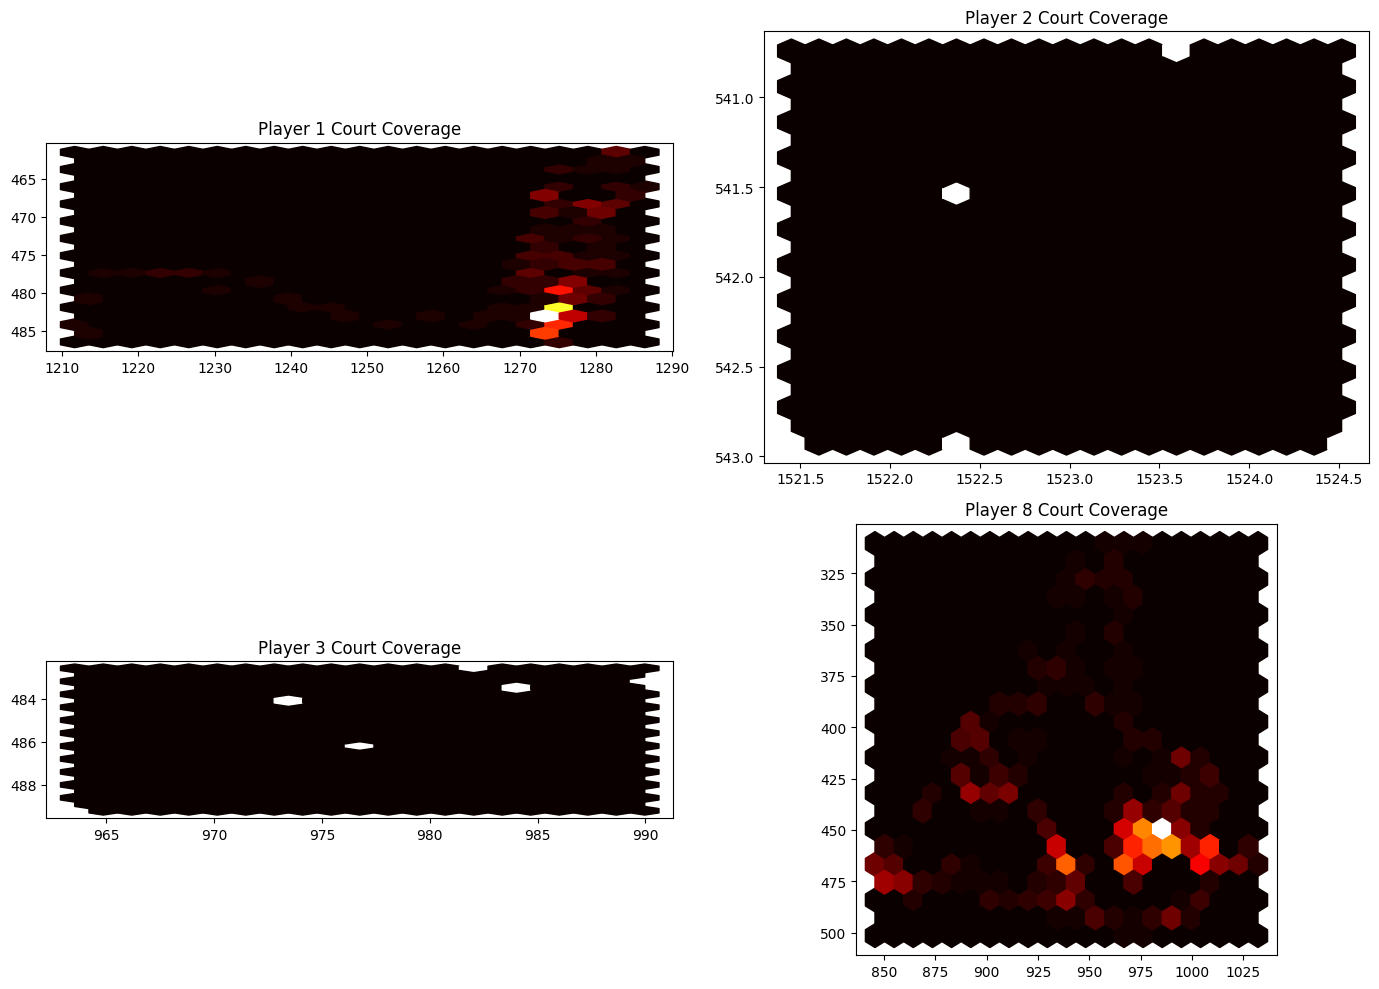

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (pid, frames) in enumerate(player_data.items()):
    if idx >= 4:
        break
    # Use hip midpoint (keypoints 11 and 12) as player position
    positions = []
    for f in frames:
        kp = f['keypoints']
        hip_x = (kp[11][0] + kp[12][0]) / 2
        hip_y = (kp[11][1] + kp[12][1]) / 2
        if hip_x > 0 and hip_y > 0:
            positions.append([hip_x, hip_y])
    positions = np.array(positions)

    axes[idx].hexbin(positions[:, 0], positions[:, 1], gridsize=20, cmap='hot')
    axes[idx].set_title(f'Player {pid} Court Coverage')
    axes[idx].invert_yaxis()
    axes[idx].set_aspect('equal')

plt.tight_layout()
plt.savefig('/content/court_coverage.png', dpi=150)
plt.show()

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np

model = YOLO('yolov8n-pose.pt')

results = list(model.track(
    source='/content/YOUR_VIDEO.mov',
    show=False,
    save=True,
    stream=True,
    tracker='bytetrack.yaml'
))

print(f"Processed {len(results)} frames")

ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
# Verify GPU is available
import torch
print(f"GPU available: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

GPU available: True
Device: Tesla T4


In [ ]:
!pip install ultralytics opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.0 MB/s eta 0:00:00


In [ ]:
import os
# List files to confirm upload
for f in os.listdir('/content'):
    print(f)

.config
sample_data


In [ ]:
from ultralytics import YOLO
import numpy as np

model = YOLO('yolov8n-pose.pt')

results = list(model.track(
    source='/content/YOUR_VIDEO.mov',
    show=False,
    save=True,
    stream=True,
    tracker='bytetrack.yaml'
))

print(f"Processed {len(results)} frames")


video 1/1 (frame 1/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 74.4ms
video 1/1 (frame 2/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 10.5ms
video 1/1 (frame 3/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 10.8ms
video 1/1 (frame 4/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 9.5ms
video 1/1 (frame 5/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 10.1ms
video 1/1 (frame 6/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 10.6ms
video 1/1 (frame 7/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 9.9ms
video 1/1 (frame 8/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 9.7ms
video 1/1 (frame 9/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 10.8ms
video 1/1 (frame 10/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 11.0ms
video 1/1 (frame 11/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 9.4ms
video 1/1 (frame 12/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 8.9ms
video 1/1 (frame 13/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 12.0ms
video 1/1 (frame 14/874) /content/YOUR

In [ ]:
player_data = {}

for frame_idx, r in enumerate(results):
    if r.keypoints is not None and r.boxes.id is not None:
        ids = r.boxes.id.cpu().numpy().astype(int)
        keypoints = r.keypoints.xy.cpu().numpy()
        boxes = r.boxes.xyxy.cpu().numpy()

        scores = []
        for i, box in enumerate(boxes):
            area = (box[2] - box[0]) * (box[3] - box[1])
            bottom_y = box[3]
            scores.append(area + bottom_y * 10)

        if len(scores) >= 2:
            top2_indices = np.argsort(scores)[-2:]
        else:
            top2_indices = range(len(scores))

        for i in top2_indices:
            pid = ids[i]
            if pid not in player_data:
                player_data[pid] = []
            player_data[pid].append({
                'frame': frame_idx,
                'keypoints': keypoints[i]
            })

sorted_players = sorted(player_data.items(), key=lambda x: len(x[1]), reverse=True)[:2]
player_data = dict(sorted_players)

print(f"Tracking players: {list(player_data.keys())}")
for pid, frames in player_data.items():
    print(f"  Player {pid}: {len(frames)} frames")

Tracking players: [np.int64(8), np.int64(1)]
  Player 8: 690 frames
  Player 1: 246 frames


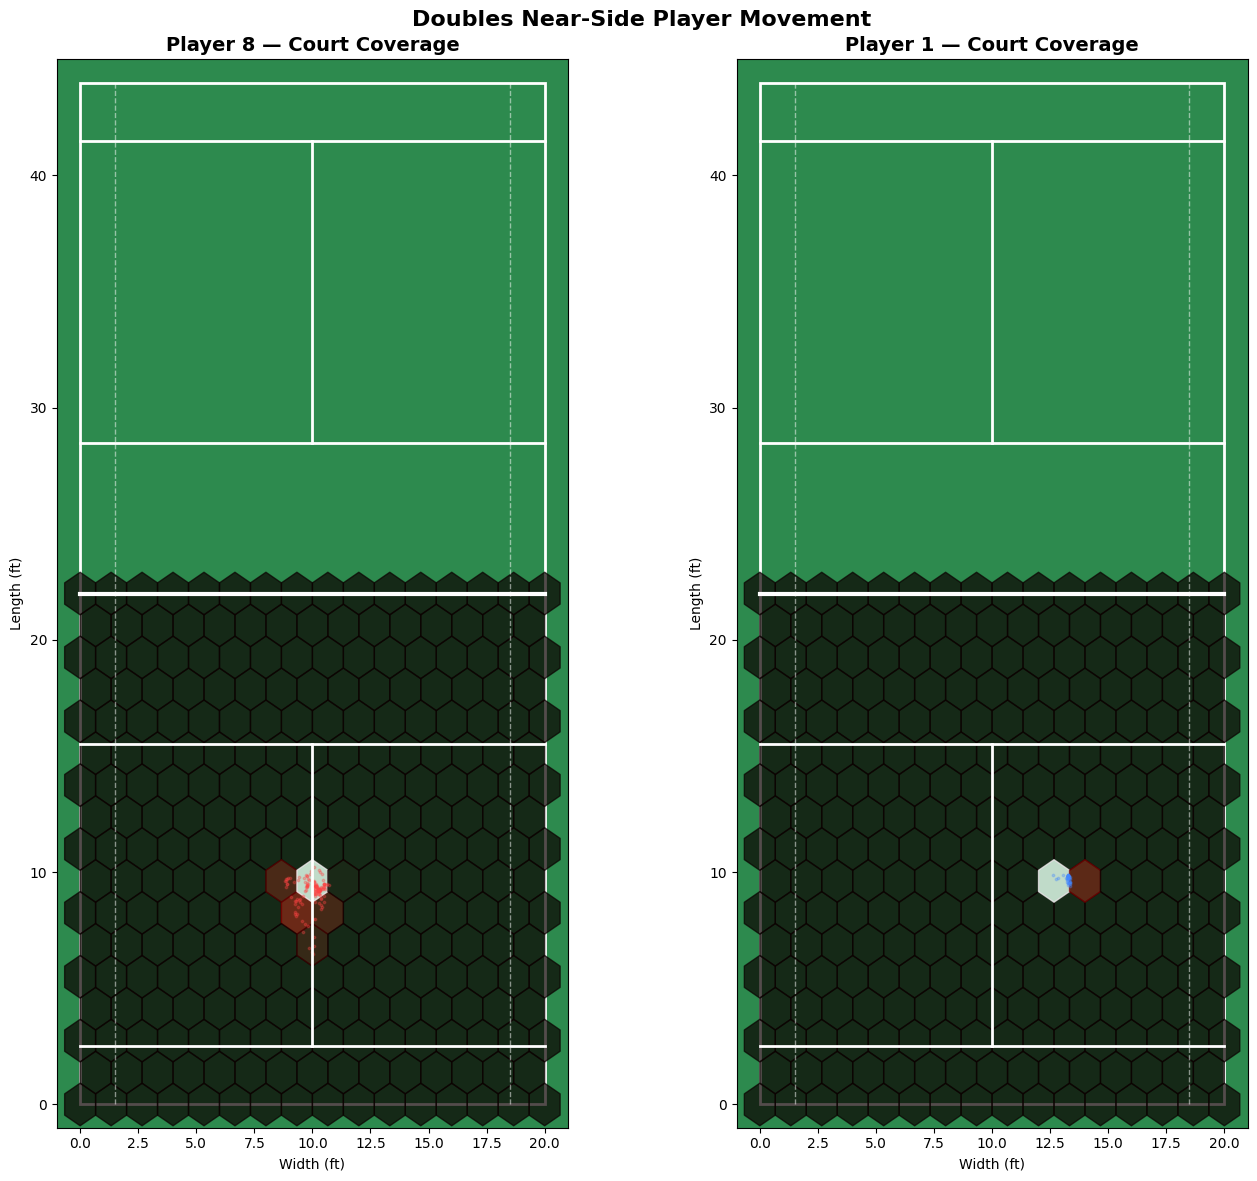

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2

def draw_badminton_court(ax):
    court_color = '#2d8a4e'
    line_color = 'white'
    lw = 2

    ax.set_facecolor(court_color)

    outer = patches.Rectangle((0, 0), 20, 44, linewidth=lw,
                                edgecolor=line_color, facecolor=court_color)
    ax.add_patch(outer)

    # Net
    ax.plot([0, 20], [22, 22], color=line_color, linewidth=lw+1)
    # Short service lines
    ax.plot([0, 20], [15.5, 15.5], color=line_color, linewidth=lw)
    ax.plot([0, 20], [28.5, 28.5], color=line_color, linewidth=lw)
    # Long service lines (doubles)
    ax.plot([0, 20], [2.5, 2.5], color=line_color, linewidth=lw)
    ax.plot([0, 20], [41.5, 41.5], color=line_color, linewidth=lw)
    # Center lines
    ax.plot([10, 10], [2.5, 15.5], color=line_color, linewidth=lw)
    ax.plot([10, 10], [28.5, 41.5], color=line_color, linewidth=lw)
    # Singles sidelines
    ax.plot([1.5, 1.5], [0, 44], color=line_color, linewidth=1,
            linestyle='--', alpha=0.5)
    ax.plot([18.5, 18.5], [0, 44], color=line_color, linewidth=1,
            linestyle='--', alpha=0.5)

    ax.set_xlim(-1, 21)
    ax.set_ylim(-1, 45)
    ax.set_aspect('equal')
    ax.set_xlabel('Width (ft)')
    ax.set_ylabel('Length (ft)')


cap = cv2.VideoCapture('/content/YOUR_VIDEO.mov')
vid_w = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
vid_h = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
cap.release()

fig, axes = plt.subplots(1, 2, figsize=(14, 12))
colors = ['#ff4444', '#4488ff']

for idx, (pid, frames) in enumerate(player_data.items()):
    ax = axes[idx]
    draw_badminton_court(ax)

    positions = []
    for f in frames:
        kp = f['keypoints']
        hip_x = (kp[11][0] + kp[12][0]) / 2
        hip_y = (kp[11][1] + kp[12][1]) / 2
        if hip_x > 0 and hip_y > 0:
            court_x = (hip_x / vid_w) * 20
            court_y = (hip_y / vid_h) * 22
            positions.append([court_x, court_y])

    positions = np.array(positions)

    ax.hexbin(positions[:, 0], positions[:, 1], gridsize=15, cmap='hot',
              alpha=0.7, extent=[0, 20, 0, 22])
    ax.scatter(positions[::5, 0], positions[::5, 1], s=3,
               color=colors[idx], alpha=0.3)
    ax.set_title(f'Player {pid} — Court Coverage', fontsize=14, fontweight='bold')

plt.suptitle('Doubles Near-Side Player Movement', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/badminton_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import files

files.download('/content/badminton_coverage.png')
# Uncomment below to also download the annotated video:
# files.download('/content/runs/pose/track/YOUR_VIDEO.avi')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2
from ultralytics import YOLO
import numpy as np

model = YOLO('yolov8n-pose.pt')

# Replace with your actual filename
input_video = '/content/YOUR_VIDEO.mov'

cap = cv2.VideoCapture(input_video)
vid_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
vid_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
cap.release()

# Get the two player IDs we're tracking
tracked_ids = set(player_data.keys())

# Re-run tracking but this time draw custom annotations
cap = cv2.VideoCapture(input_video)
out = cv2.VideoWriter(
    '/content/badminton_annotated.mp4',
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (vid_w, vid_h)
)

# Skeleton connections for YOLOv8-Pose (17 keypoints)
skeleton = [
    (0, 1), (0, 2), (1, 3), (2, 4),        # head
    (5, 6),                                   # shoulders
    (5, 7), (7, 9),                           # left arm
    (6, 8), (8, 10),                          # right arm
    (5, 11), (6, 12),                         # torso
    (11, 12),                                 # hips
    (11, 13), (13, 15),                       # left leg
    (12, 14), (14, 16)                        # right leg
]

colors_map = {}
color_options = [(0, 0, 255), (255, 100, 0)]  # red, blue in BGR
color_idx = 0

frame_idx = 0
results2 = model.track(
    source=input_video,
    show=False,
    save=False,
    stream=True,
    tracker='bytetrack.yaml'
)

for r in results2:
    frame = r.orig_img.copy()

    if r.keypoints is not None and r.boxes.id is not None:
        ids = r.boxes.id.cpu().numpy().astype(int)
        keypoints = r.keypoints.xy.cpu().numpy()
        boxes = r.boxes.xyxy.cpu().numpy()

        # Filter to nearest 2 players (same logic as before)
        scores = []
        for i, box in enumerate(boxes):
            area = (box[2] - box[0]) * (box[3] - box[1])
            bottom_y = box[3]
            scores.append(area + bottom_y * 10)

        if len(scores) >= 2:
            top2_indices = np.argsort(scores)[-2:]
        else:
            top2_indices = range(len(scores))

        for i in top2_indices:
            pid = ids[i]
            kp = keypoints[i]

            # Assign consistent color per player
            if pid not in colors_map:
                colors_map[pid] = color_options[color_idx % 2]
                color_idx += 1
            color = colors_map[pid]

            # Draw skeleton lines
            for (a, b) in skeleton:
                x1, y1 = int(kp[a][0]), int(kp[a][1])
                x2, y2 = int(kp[b][0]), int(kp[b][1])
                if x1 > 0 and y1 > 0 and x2 > 0 and y2 > 0:
                    cv2.line(frame, (x1, y1), (x2, y2), color, 2)

            # Draw keypoint dots
            for point in kp:
                x, y = int(point[0]), int(point[1])
                if x > 0 and y > 0:
                    cv2.circle(frame, (x, y), 4, color, -1)

            # Draw player ID label
            box = boxes[i]
            cv2.putText(frame, f'Player {pid}',
                        (int(box[0]), int(box[1] - 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    out.write(frame)
    frame_idx += 1

out.release()
cap.release()
print(f"Done. {frame_idx} frames written to /content/badminton_annotated.mp4")


video 1/1 (frame 1/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 10.9ms
video 1/1 (frame 2/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 11.6ms
video 1/1 (frame 3/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 10.3ms
video 1/1 (frame 4/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 13.0ms
video 1/1 (frame 5/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 22.9ms
video 1/1 (frame 6/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 22.0ms
video 1/1 (frame 7/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 17.8ms
video 1/1 (frame 8/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 12.9ms
video 1/1 (frame 9/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 29.5ms
video 1/1 (frame 10/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 21.6ms
video 1/1 (frame 11/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 20.3ms
video 1/1 (frame 12/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 16.2ms
video 1/1 (frame 13/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 22.8ms
video 1/1 (frame 14/874) /content

In [ ]:
from google.colab import files
files.download('/content/badminton_annotated.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2
from ultralytics import YOLO
import numpy as np
from collections import Counter

model = YOLO('yolov8n-pose.pt')

# Replace with your actual filename
input_video = '/content/YOUR_VIDEO.mov'

# First pass: find the 2 most frequent player IDs in the near-camera zone
id_frame_counts = Counter()

first_pass = model.track(
    source=input_video,
    show=False,
    save=False,
    stream=True,
    tracker='bytetrack.yaml'
)

for r in first_pass:
    if r.keypoints is not None and r.boxes.id is not None:
        ids = r.boxes.id.cpu().numpy().astype(int)
        boxes = r.boxes.xyxy.cpu().numpy()

        scores = []
        for i, box in enumerate(boxes):
            area = (box[2] - box[0]) * (box[3] - box[1])
            bottom_y = box[3]
            scores.append(area + bottom_y * 10)

        if len(scores) >= 2:
            top2_indices = np.argsort(scores)[-2:]
        else:
            top2_indices = range(len(scores))

        for i in top2_indices:
            id_frame_counts[ids[i]] += 1

# The 2 IDs that appear most often in the near zone are our players
keep_ids = set([pid for pid, _ in id_frame_counts.most_common(2)])
print(f"Keeping only player IDs: {keep_ids}")

# Second pass: draw only those 2 players
cap = cv2.VideoCapture(input_video)
vid_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
vid_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
cap.release()

skeleton = [
    (0, 1), (0, 2), (1, 3), (2, 4),
    (5, 6),
    (5, 7), (7, 9),
    (6, 8), (8, 10),
    (5, 11), (6, 12),
    (11, 12),
    (11, 13), (13, 15),
    (12, 14), (14, 16)
]

color_assign = {}
color_options = [(0, 0, 255), (255, 100, 0)]
for idx, pid in enumerate(keep_ids):
    color_assign[pid] = color_options[idx % 2]

out = cv2.VideoWriter(
    '/content/badminton_annotated.mp4',
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (vid_w, vid_h)
)

frame_count = 0
second_pass = model.track(
    source=input_video,
    show=False,
    save=False,
    stream=True,
    tracker='bytetrack.yaml'
)

for r in second_pass:
    frame = r.orig_img.copy()

    if r.keypoints is not None and r.boxes.id is not None:
        ids = r.boxes.id.cpu().numpy().astype(int)
        keypoints = r.keypoints.xy.cpu().numpy()
        boxes = r.boxes.xyxy.cpu().numpy()

        for i, pid in enumerate(ids):
            if pid not in keep_ids:
                continue

            kp = keypoints[i]
            color = color_assign[pid]

            for (a, b) in skeleton:
                x1, y1 = int(kp[a][0]), int(kp[a][1])
                x2, y2 = int(kp[b][0]), int(kp[b][1])
                if x1 > 0 and y1 > 0 and x2 > 0 and y2 > 0:
                    cv2.line(frame, (x1, y1), (x2, y2), color, 2)

            for point in kp:
                x, y = int(point[0]), int(point[1])
                if x > 0 and y > 0:
                    cv2.circle(frame, (x, y), 4, color, -1)

            box = boxes[i]
            cv2.putText(frame, f'Player {pid}',
                        (int(box[0]), int(box[1] - 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    out.write(frame)
    frame_count += 1

out.release()
print(f"Done. {frame_count} frames. Only players {keep_ids} annotated.")



video 1/1 (frame 1/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 11.1ms
video 1/1 (frame 2/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 21.6ms
video 1/1 (frame 3/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 20.5ms
video 1/1 (frame 4/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 21.1ms
video 1/1 (frame 5/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 12.4ms
video 1/1 (frame 6/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 19.2ms
video 1/1 (frame 7/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 14.6ms
video 1/1 (frame 8/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 17.6ms
video 1/1 (frame 9/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 25.1ms
video 1/1 (frame 10/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 21.3ms
video 1/1 (frame 11/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 16.8ms
video 1/1 (frame 12/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 19.8ms
video 1/1 (frame 13/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 11.8ms
video 1/1 (frame 14/874) /content

In [ ]:
from google.colab import files
files.download('/content/badminton_annotated.mp4')

FileNotFoundError: Cannot find file: /content/badminton_annotated.mp4

In [ ]:
!pip install ultralytics opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.6 MB/s eta 0:00:00


In [ ]:
import os
[f for f in os.listdir('/content') if f.endswith(('.mov', '.mp4', '.avi'))]

[]

In [ ]:
from ultralytics import YOLO
import numpy as np
from collections import Counter

model = YOLO('yolov8n-pose.pt')
input_video = '/content/YOUR_VIDEO.mov'

# First pass: find the 2 most consistent near-camera player IDs
id_frame_counts = Counter()

first_pass = model.track(
    source=input_video,
    show=False,
    save=False,
    stream=True,
    tracker='bytetrack.yaml'
)

for r in first_pass:
    if r.keypoints is not None and r.boxes.id is not None:
        ids = r.boxes.id.cpu().numpy().astype(int)
        boxes = r.boxes.xyxy.cpu().numpy()

        scores = []
        for i, box in enumerate(boxes):
            area = (box[2] - box[0]) * (box[3] - box[1])
            bottom_y = box[3]
            scores.append(area + bottom_y * 10)

        if len(scores) >= 2:
            top2_indices = np.argsort(scores)[-2:]
        else:
            top2_indices = range(len(scores))

        for i in top2_indices:
            id_frame_counts[ids[i]] += 1

keep_ids = set([pid for pid, _ in id_frame_counts.most_common(2)])
print(f"Keeping only player IDs: {keep_ids}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 367ms
Prepared 1 package in 57ms
Installed 1 package in 5ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


video 1/1 (frame 1/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 84.5ms
video 1/1 (frame 2/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 10.7ms
video 1/1 (frame 3/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 8.9ms
video 1/1 (frame 4/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 10.8ms
video 1/1 (frame 5/874) /content/YOU

In [ ]:
# Extract keypoint data for the 2 players
player_data = {}

second_pass = model.track(
    source=input_video,
    show=False,
    save=False,
    stream=True,
    tracker='bytetrack.yaml'
)

for frame_idx, r in enumerate(second_pass):
    if r.keypoints is not None and r.boxes.id is not None:
        ids = r.boxes.id.cpu().numpy().astype(int)
        keypoints = r.keypoints.xy.cpu().numpy()

        for i, pid in enumerate(ids):
            if pid not in keep_ids:
                continue
            if pid not in player_data:
                player_data[pid] = []
            player_data[pid].append({
                'frame': frame_idx,
                'keypoints': keypoints[i]
            })

for pid, frames in player_data.items():
    print(f"Player {pid}: {len(frames)} frames")


video 1/1 (frame 1/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 19.8ms
video 1/1 (frame 2/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 37.6ms
video 1/1 (frame 3/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 64.6ms
video 1/1 (frame 4/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 64.7ms
video 1/1 (frame 5/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 53.3ms
video 1/1 (frame 6/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 60.9ms
video 1/1 (frame 7/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 56.7ms
video 1/1 (frame 8/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 16.1ms
video 1/1 (frame 9/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 15.7ms
video 1/1 (frame 10/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 24.3ms
video 1/1 (frame 11/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 19.2ms
video 1/1 (frame 12/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 14.8ms
video 1/1 (frame 13/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 16.6ms
video 1/1 (frame 14/874) /content

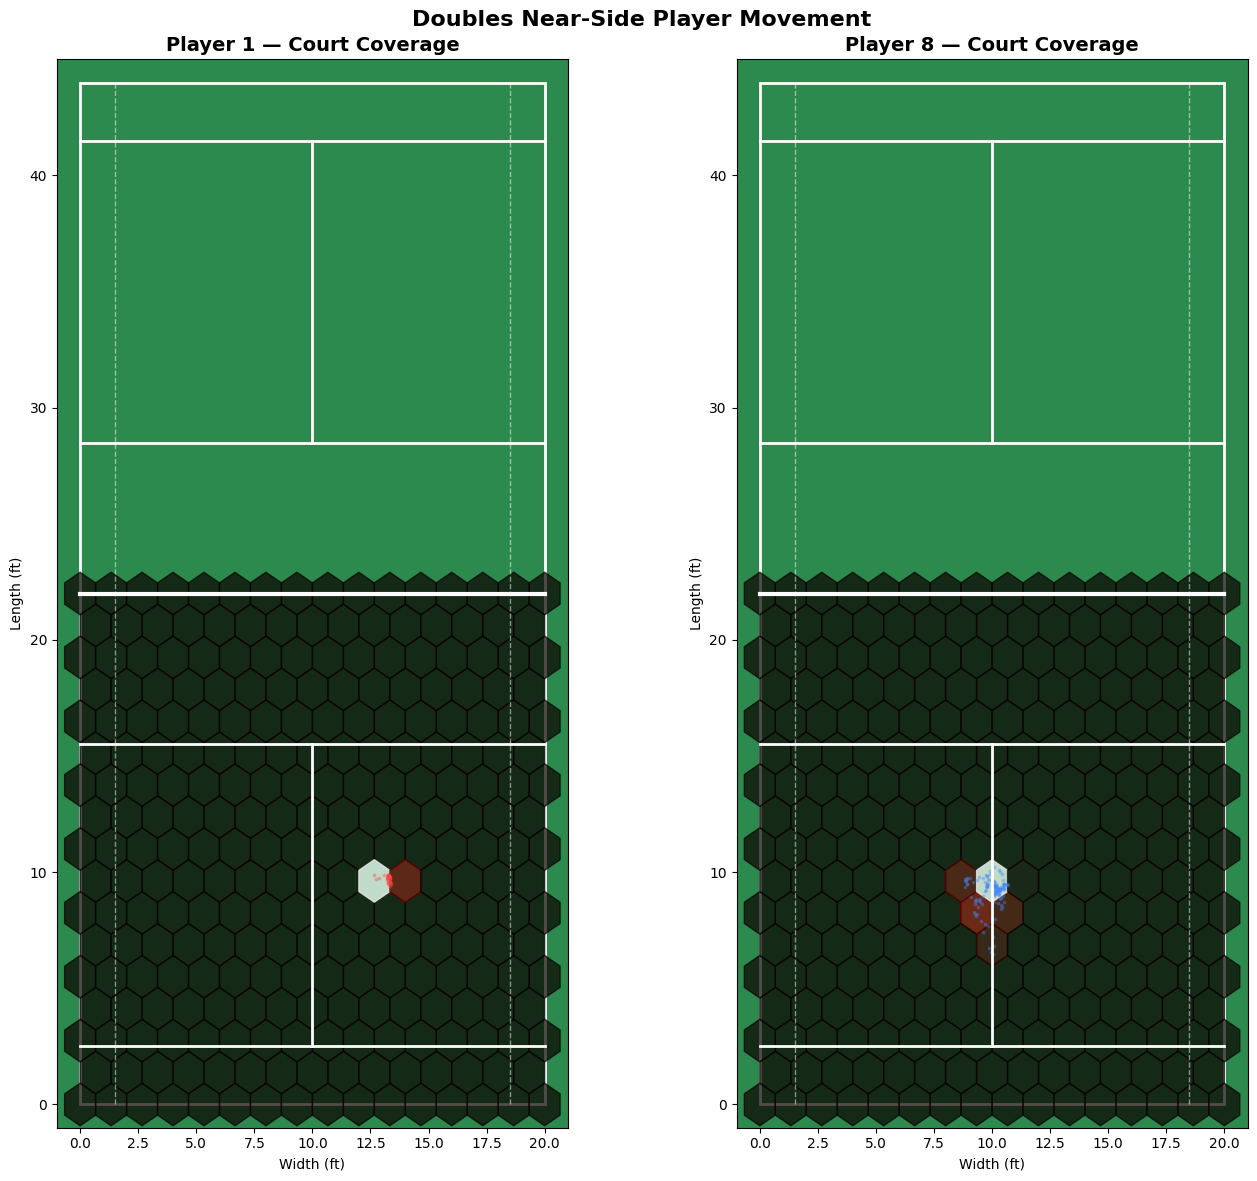

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2

def draw_badminton_court(ax):
    court_color = '#2d8a4e'
    line_color = 'white'
    lw = 2
    ax.set_facecolor(court_color)
    outer = patches.Rectangle((0, 0), 20, 44, linewidth=lw,
                                edgecolor=line_color, facecolor=court_color)
    ax.add_patch(outer)
    ax.plot([0, 20], [22, 22], color=line_color, linewidth=lw+1)
    ax.plot([0, 20], [15.5, 15.5], color=line_color, linewidth=lw)
    ax.plot([0, 20], [28.5, 28.5], color=line_color, linewidth=lw)
    ax.plot([0, 20], [2.5, 2.5], color=line_color, linewidth=lw)
    ax.plot([0, 20], [41.5, 41.5], color=line_color, linewidth=lw)
    ax.plot([10, 10], [2.5, 15.5], color=line_color, linewidth=lw)
    ax.plot([10, 10], [28.5, 41.5], color=line_color, linewidth=lw)
    ax.plot([1.5, 1.5], [0, 44], color=line_color, linewidth=1, linestyle='--', alpha=0.5)
    ax.plot([18.5, 18.5], [0, 44], color=line_color, linewidth=1, linestyle='--', alpha=0.5)
    ax.set_xlim(-1, 21)
    ax.set_ylim(-1, 45)
    ax.set_aspect('equal')
    ax.set_xlabel('Width (ft)')
    ax.set_ylabel('Length (ft)')

cap = cv2.VideoCapture(input_video)
vid_w = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
vid_h = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
cap.release()

fig, axes = plt.subplots(1, 2, figsize=(14, 12))
colors = ['#ff4444', '#4488ff']

for idx, (pid, frames) in enumerate(player_data.items()):
    ax = axes[idx]
    draw_badminton_court(ax)
    positions = []
    for f in frames:
        kp = f['keypoints']
        hip_x = (kp[11][0] + kp[12][0]) / 2
        hip_y = (kp[11][1] + kp[12][1]) / 2
        if hip_x > 0 and hip_y > 0:
            court_x = (hip_x / vid_w) * 20
            court_y = (hip_y / vid_h) * 22
            positions.append([court_x, court_y])
    positions = np.array(positions)
    ax.hexbin(positions[:, 0], positions[:, 1], gridsize=15, cmap='hot',
              alpha=0.7, extent=[0, 20, 0, 22])
    ax.scatter(positions[::5, 0], positions[::5, 1], s=3, color=colors[idx], alpha=0.3)
    ax.set_title(f'Player {pid} — Court Coverage', fontsize=14, fontweight='bold')

plt.suptitle('Doubles Near-Side Player Movement', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/badminton_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Annotated video — only the 2 tracked players
skeleton = [
    (0, 1), (0, 2), (1, 3), (2, 4),
    (5, 6),
    (5, 7), (7, 9),
    (6, 8), (8, 10),
    (5, 11), (6, 12),
    (11, 12),
    (11, 13), (13, 15),
    (12, 14), (14, 16)
]

cap = cv2.VideoCapture(input_video)
vid_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
vid_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
cap.release()

color_assign = {}
color_options = [(0, 0, 255), (255, 100, 0)]
for idx, pid in enumerate(keep_ids):
    color_assign[pid] = color_options[idx % 2]

out = cv2.VideoWriter(
    '/content/badminton_annotated.mp4',
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (vid_w, vid_h)
)

third_pass = model.track(
    source=input_video,
    show=False,
    save=False,
    stream=True,
    tracker='bytetrack.yaml'
)

frame_count = 0
for r in third_pass:
    frame = r.orig_img.copy()
    if r.keypoints is not None and r.boxes.id is not None:
        ids = r.boxes.id.cpu().numpy().astype(int)
        keypoints = r.keypoints.xy.cpu().numpy()
        boxes = r.boxes.xyxy.cpu().numpy()

        for i, pid in enumerate(ids):
            if pid not in keep_ids:
                continue
            kp = keypoints[i]
            color = color_assign[pid]
            for (a, b) in skeleton:
                x1, y1 = int(kp[a][0]), int(kp[a][1])
                x2, y2 = int(kp[b][0]), int(kp[b][1])
                if x1 > 0 and y1 > 0 and x2 > 0 and y2 > 0:
                    cv2.line(frame, (x1, y1), (x2, y2), color, 2)
            for point in kp:
                x, y = int(point[0]), int(point[1])
                if x > 0 and y > 0:
                    cv2.circle(frame, (x, y), 4, color, -1)
            box = boxes[i]
            cv2.putText(frame, f'Player {pid}',
                        (int(box[0]), int(box[1] - 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    out.write(frame)
    frame_count += 1

out.release()
print(f"Done. {frame_count} frames. Only players {keep_ids} annotated.")


video 1/1 (frame 1/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 84.5ms
video 1/1 (frame 2/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 48.3ms
video 1/1 (frame 3/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 41.0ms
video 1/1 (frame 4/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 26.1ms
video 1/1 (frame 5/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 37.0ms
video 1/1 (frame 6/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 61.1ms
video 1/1 (frame 7/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 112.0ms
video 1/1 (frame 8/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 35.7ms
video 1/1 (frame 9/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 33.8ms
video 1/1 (frame 10/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 21.7ms
video 1/1 (frame 11/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 12.9ms
video 1/1 (frame 12/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 8.9ms
video 1/1 (frame 13/874) /content/YOUR_VIDEO.mov: 384x640 1 person, 10.7ms
video 1/1 (frame 14/874) /content

In [ ]:
from google.colab import files
files.download('/content/badminton_coverage.png')
files.download('/content/badminton_annotated.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install ultralytics opencv-python-headless

In [ ]:
import os
[f for f in os.listdir('/content') if f.endswith(('.mov', '.mp4', '.avi'))]

['YOUR_VIDEO.mov']

In [ ]:
from ultralytics import YOLO
import numpy as np
from collections import Counter

model = YOLO('yolov8n-pose.pt')
input_video = '/content/YOUR_VIDEO.mov'

# First pass: find the single player who is near-camera AND left-side
id_scores = Counter()
id_positions = {}

first_pass = model.track(
    source=input_video,
    show=False,
    save=False,
    stream=True,
    tracker='bytetrack.yaml'
)

for r in first_pass:
    if r.keypoints is not None and r.boxes.id is not None:
        ids = r.boxes.id.cpu().numpy().astype(int)
        boxes = r.boxes.xyxy.cpu().numpy()

        for i, pid in enumerate(ids):
            box = boxes[i]
            area = (box[2] - box[0]) * (box[3] - box[1])
            bottom_y = box[3]
            center_x = (box[0] + box[2]) / 2

            # Near-camera = large area + high Y
            nearness = area + bottom_y * 10

            if pid not in id_positions:
                id_positions[pid] = {'x_sum': 0, 'y_sum': 0, 'near_sum': 0, 'count': 0}

            id_positions[pid]['x_sum'] += center_x
            id_positions[pid]['near_sum'] += nearness
            id_positions[pid]['count'] += 1

# Filter: must be near camera (top 50% by nearness), then pick the leftmost
vid_w = None
import cv2
cap = cv2.VideoCapture(input_video)
vid_w = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
cap.release()

candidates = []
for pid, data in id_positions.items():
    if data['count'] < 20:  # skip noise detections
        continue
    avg_x = data['x_sum'] / data['count']
    avg_near = data['near_sum'] / data['count']
    candidates.append((pid, avg_x, avg_near, data['count']))

# Sort by nearness descending, keep top half
candidates.sort(key=lambda x: x[2], reverse=True)
near_candidates = candidates[:max(len(candidates) // 2, 2)]

# From near candidates, pick the one with lowest avg X (leftmost)
near_candidates.sort(key=lambda x: x[1])
your_id = near_candidates[0][0]

print(f"You are Player {your_id}")
print(f"  Avg X position: {near_candidates[0][1]:.0f} / {vid_w:.0f}")
print(f"  Detected in {near_candidates[0][3]} frames")


video 1/1 (frame 1/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 111.5ms
video 1/1 (frame 2/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 24.5ms
video 1/1 (frame 3/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 10.8ms
video 1/1 (frame 4/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 10.2ms
video 1/1 (frame 5/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 14.0ms
video 1/1 (frame 6/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 9.2ms
video 1/1 (frame 7/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 10.0ms
video 1/1 (frame 8/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 7.9ms
video 1/1 (frame 9/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 9.2ms
video 1/1 (frame 10/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 10.0ms
video 1/1 (frame 11/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 10.3ms
video 1/1 (frame 12/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 10.7ms
video 1/1 (frame 13/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 10.6ms
video 1/1 (frame 14/57

In [ ]:
# Annotated video — only you
import cv2

skeleton = [
    (0, 1), (0, 2), (1, 3), (2, 4),
    (5, 6),
    (5, 7), (7, 9),
    (6, 8), (8, 10),
    (5, 11), (6, 12),
    (11, 12),
    (11, 13), (13, 15),
    (12, 14), (14, 16)
]

cap = cv2.VideoCapture(input_video)
vid_w_int = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
vid_h_int = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
cap.release()

color = (0, 255, 0)  # green skeleton for you

out = cv2.VideoWriter(
    '/content/my_movement.mp4',
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (vid_w_int, vid_h_int)
)

second_pass = model.track(
    source=input_video,
    show=False,
    save=False,
    stream=True,
    tracker='bytetrack.yaml'
)

frame_count = 0
for r in second_pass:
    frame = r.orig_img.copy()
    if r.keypoints is not None and r.boxes.id is not None:
        ids = r.boxes.id.cpu().numpy().astype(int)
        keypoints = r.keypoints.xy.cpu().numpy()
        boxes = r.boxes.xyxy.cpu().numpy()

        for i, pid in enumerate(ids):
            if pid != your_id:
                continue
            kp = keypoints[i]

            for (a, b) in skeleton:
                x1, y1 = int(kp[a][0]), int(kp[a][1])
                x2, y2 = int(kp[b][0]), int(kp[b][1])
                if x1 > 0 and y1 > 0 and x2 > 0 and y2 > 0:
                    cv2.line(frame, (x1, y1), (x2, y2), color, 3)

            for point in kp:
                x, y = int(point[0]), int(point[1])
                if x > 0 and y > 0:
                    cv2.circle(frame, (x, y), 5, color, -1)

            box = boxes[i]
            cv2.putText(frame, 'YOU',
                        (int(box[0]), int(box[1] - 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

    out.write(frame)
    frame_count += 1

out.release()
print(f"Done. {frame_count} frames. Only Player {your_id} annotated.")


video 1/1 (frame 1/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 7.4ms
video 1/1 (frame 2/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 11.4ms
video 1/1 (frame 3/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 10.9ms
video 1/1 (frame 4/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 11.2ms
video 1/1 (frame 5/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 9.8ms
video 1/1 (frame 6/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 9.1ms
video 1/1 (frame 7/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 10.5ms
video 1/1 (frame 8/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 11.1ms
video 1/1 (frame 9/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 8.1ms
video 1/1 (frame 10/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 9.8ms
video 1/1 (frame 11/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 10.4ms
video 1/1 (frame 12/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 10.3ms
video 1/1 (frame 13/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 10.0ms
video 1/1 (frame 14/578) 

In [ ]:
from google.colab import files
files.download('/content/my_movement.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install ultralytics opencv-python-headless

In [ ]:
import os
[f for f in os.listdir('/content') if f.endswith(('.mov', '.mp4', '.avi'))]

['YOUR_VIDEO.mov']

In [ ]:
from ultralytics import YOLO
import numpy as np
import cv2
from collections import Counter

model = YOLO('yolov8n-pose.pt')
input_video = '/content/YOUR_VIDEO.mov'

id_positions = {}

first_pass = model.track(
    source=input_video,
    show=False,
    save=False,
    stream=True,
    tracker='bytetrack.yaml'
)

for r in first_pass:
    if r.keypoints is not None and r.boxes.id is not None:
        ids = r.boxes.id.cpu().numpy().astype(int)
        boxes = r.boxes.xyxy.cpu().numpy()

        for i, pid in enumerate(ids):
            box = boxes[i]
            area = (box[2] - box[0]) * (box[3] - box[1])
            bottom_y = box[3]
            center_x = (box[0] + box[2]) / 2
            nearness = area + bottom_y * 10

            if pid not in id_positions:
                id_positions[pid] = {'x_sum': 0, 'near_sum': 0, 'count': 0}

            id_positions[pid]['x_sum'] += center_x
            id_positions[pid]['near_sum'] += nearness
            id_positions[pid]['count'] += 1

cap = cv2.VideoCapture(input_video)
vid_w = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
cap.release()

candidates = []
for pid, data in id_positions.items():
    if data['count'] < 20:
        continue
    avg_x = data['x_sum'] / data['count']
    avg_near = data['near_sum'] / data['count']
    candidates.append((pid, avg_x, avg_near, data['count']))

candidates.sort(key=lambda x: x[2], reverse=True)
near_candidates = candidates[:max(len(candidates) // 2, 2)]

# Rightmost near-camera player = you
near_candidates.sort(key=lambda x: x[1], reverse=True)
your_id = near_candidates[0][0]

print(f"You are Player {your_id}")
print(f"  Avg X position: {near_candidates[0][1]:.0f} / {vid_w:.0f}")
print(f"  Detected in {near_candidates[0][3]} frames")


video 1/1 (frame 1/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 19.9ms
video 1/1 (frame 2/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 28.2ms
video 1/1 (frame 3/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 22.1ms
video 1/1 (frame 4/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 21.0ms
video 1/1 (frame 5/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 36.2ms
video 1/1 (frame 6/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 34.9ms
video 1/1 (frame 7/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 12.5ms
video 1/1 (frame 8/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 12.8ms
video 1/1 (frame 9/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 30.2ms
video 1/1 (frame 10/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 18.6ms
video 1/1 (frame 11/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 30.5ms
video 1/1 (frame 12/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 40.7ms
video 1/1 (frame 13/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 30.9ms
video 1/1 (frame 14/

In [ ]:
import cv2

skeleton = [
    (0, 1), (0, 2), (1, 3), (2, 4),
    (5, 6),
    (5, 7), (7, 9),
    (6, 8), (8, 10),
    (5, 11), (6, 12),
    (11, 12),
    (11, 13), (13, 15),
    (12, 14), (14, 16)
]

cap = cv2.VideoCapture(input_video)
vid_w_int = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
vid_h_int = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
cap.release()

color = (0, 255, 0)

out = cv2.VideoWriter(
    '/content/my_movement.mp4',
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (vid_w_int, vid_h_int)
)

second_pass = model.track(
    source=input_video,
    show=False,
    save=False,
    stream=True,
    tracker='bytetrack.yaml'
)

frame_count = 0
for r in second_pass:
    frame = r.orig_img.copy()
    if r.keypoints is not None and r.boxes.id is not None:
        ids = r.boxes.id.cpu().numpy().astype(int)
        keypoints = r.keypoints.xy.cpu().numpy()
        boxes = r.boxes.xyxy.cpu().numpy()

        for i, pid in enumerate(ids):
            if pid != your_id:
                continue
            kp = keypoints[i]

            for (a, b) in skeleton:
                x1, y1 = int(kp[a][0]), int(kp[a][1])
                x2, y2 = int(kp[b][0]), int(kp[b][1])
                if x1 > 0 and y1 > 0 and x2 > 0 and y2 > 0:
                    cv2.line(frame, (x1, y1), (x2, y2), color, 3)

            for point in kp:
                x, y = int(point[0]), int(point[1])
                if x > 0 and y > 0:
                    cv2.circle(frame, (x, y), 5, color, -1)

            box = boxes[i]
            cv2.putText(frame, 'YOU',
                        (int(box[0]), int(box[1] - 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

    out.write(frame)
    frame_count += 1

out.release()
print(f"Done. {frame_count} frames. Only Player {your_id} annotated.")


video 1/1 (frame 1/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 41.8ms
video 1/1 (frame 2/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 30.4ms
video 1/1 (frame 3/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 38.2ms
video 1/1 (frame 4/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 20.4ms
video 1/1 (frame 5/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 23.9ms
video 1/1 (frame 6/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 23.9ms
video 1/1 (frame 7/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 30.2ms
video 1/1 (frame 8/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 44.9ms
video 1/1 (frame 9/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 11.6ms
video 1/1 (frame 10/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 18.6ms
video 1/1 (frame 11/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 10.1ms
video 1/1 (frame 12/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 9.8ms
video 1/1 (frame 13/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 10.8ms
video 1/1 (frame 14/5

In [ ]:
from google.colab import files
files.download('/content/my_movement.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2
import numpy as np

cap = cv2.VideoCapture(input_video)
vid_w_int = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
vid_h_int = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
cap.release()

# Collect all your keypoint data from the second_pass
your_frames = []

art_pass = model.track(
    source=input_video,
    show=False,
    save=False,
    stream=True,
    tracker='bytetrack.yaml'
)

for r in art_pass:
    if r.keypoints is not None and r.boxes.id is not None:
        ids = r.boxes.id.cpu().numpy().astype(int)
        keypoints = r.keypoints.xy.cpu().numpy()
        for i, pid in enumerate(ids):
            if pid == your_id:
                your_frames.append(keypoints[i])
                break
        else:
            your_frames.append(None)
    else:
        your_frames.append(None)

# Skeleton connections
skeleton = [
    (0, 1), (0, 2), (1, 3), (2, 4),
    (5, 6),
    (5, 7), (7, 9),
    (6, 8), (8, 10),
    (5, 11), (6, 12),
    (11, 12),
    (11, 13), (13, 15),
    (12, 14), (14, 16)
]

# Body part groups for coloring
body_colors = {
    'head': [(0,1), (0,2), (1,3), (2,4)],
    'torso': [(5,6), (5,11), (6,12), (11,12)],
    'left_arm': [(5,7), (7,9)],
    'right_arm': [(6,8), (8,10)],
    'left_leg': [(11,13), (13,15)],
    'right_leg': [(12,14), (14,16)]
}

def get_velocity(kp_prev, kp_curr):
    if kp_prev is None or kp_curr is None:
        return 0
    valid = (kp_prev[:, 0] > 0) & (kp_curr[:, 0] > 0)
    if valid.sum() == 0:
        return 0
    diff = np.linalg.norm(kp_curr[valid] - kp_prev[valid], axis=1)
    return np.mean(diff)

def velocity_to_color(v, max_v=30):
    """Map velocity to green court palette:
    still = dark green, moving = bright white-green, fast = pure white"""
    t = min(v / max_v, 1.0)
    r = int(200 * t + 20)
    g = int(100 + 155 * t)
    b = int(80 * t + 20)
    return (b, g, r)  # BGR

def velocity_to_thickness(v, max_v=30):
    t = min(v / max_v, 1.0)
    return int(2 + 10 * t)

def velocity_to_circle_radius(v, max_v=30):
    t = min(v / max_v, 1.0)
    return int(4 + 20 * t)

# Court green background
court_green = np.zeros((vid_h_int, vid_w_int, 3), dtype=np.uint8)
court_green[:] = (30, 100, 45)  # dark green BGR

# Trail canvas accumulates fading past positions
trail_canvas = court_green.copy()

out = cv2.VideoWriter(
    '/content/movement_art.mp4',
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (vid_w_int, vid_h_int)
)

prev_kp = None
trail_history = []  # store (keypoints, velocity) for trailing effect

for frame_idx, kp in enumerate(your_frames):
    # Fade the trail canvas toward court green
    trail_canvas = cv2.addWeighted(trail_canvas, 0.97, court_green, 0.03, 0)

    if kp is not None:
        vel = get_velocity(prev_kp, kp)

        # Draw court lines faintly
        frame = trail_canvas.copy()

        # Net line
        net_y = vid_h_int // 2
        cv2.line(frame, (0, net_y), (vid_w_int, net_y), (200, 200, 200), 1)

        # Draw expanding shapes at joint positions based on velocity
        for j, point in enumerate(kp):
            x, y = int(point[0]), int(point[1])
            if x > 0 and y > 0:
                # Joint-specific velocity
                if prev_kp is not None and prev_kp[j][0] > 0:
                    joint_vel = np.linalg.norm(kp[j] - prev_kp[j])
                else:
                    joint_vel = vel

                color = velocity_to_color(joint_vel)
                radius = velocity_to_circle_radius(joint_vel)

                # Draw circle with transparency effect
                overlay = frame.copy()
                cv2.circle(overlay, (x, y), radius, color, -1)
                cv2.addWeighted(overlay, 0.6, frame, 0.4, 0, frame)

                # Also burn onto trail canvas (smaller, fainter)
                cv2.circle(trail_canvas, (x, y), max(radius // 3, 2), color, -1)

        # Draw skeleton with velocity-mapped thickness and color
        for (a, b) in skeleton:
            x1, y1 = int(kp[a][0]), int(kp[a][1])
            x2, y2 = int(kp[b][0]), int(kp[b][1])
            if x1 > 0 and y1 > 0 and x2 > 0 and y2 > 0:
                seg_vel = 0
                if prev_kp is not None:
                    if prev_kp[a][0] > 0 and prev_kp[b][0] > 0:
                        seg_vel = (np.linalg.norm(kp[a] - prev_kp[a]) +
                                   np.linalg.norm(kp[b] - prev_kp[b])) / 2

                color = velocity_to_color(seg_vel)
                thick = velocity_to_thickness(seg_vel)
                cv2.line(frame, (x1, y1), (x2, y2), color, thick)

        # Draw hip trail line (movement path)
        hip_x = int((kp[11][0] + kp[12][0]) / 2)
        hip_y = int((kp[11][1] + kp[12][1]) / 2)
        if hip_x > 0 and hip_y > 0 and prev_kp is not None:
            prev_hip_x = int((prev_kp[11][0] + prev_kp[12][0]) / 2)
            prev_hip_y = int((prev_kp[11][1] + prev_kp[12][1]) / 2)
            if prev_hip_x > 0 and prev_hip_y > 0:
                cv2.line(trail_canvas, (prev_hip_x, prev_hip_y),
                         (hip_x, hip_y), (200, 220, 200), 2)

        prev_kp = kp.copy()
    else:
        frame = trail_canvas.copy()
        prev_kp = None

    # Add frame counter
    cv2.putText(frame, f'Frame {frame_idx}',
                (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1)

    out.write(frame)

out.release()
print(f"Done. {len(your_frames)} frames rendered to /content/movement_art.mp4")


video 1/1 (frame 1/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 14.3ms
video 1/1 (frame 2/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 35.2ms
video 1/1 (frame 3/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 20.8ms
video 1/1 (frame 4/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 13.0ms
video 1/1 (frame 5/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 26.5ms
video 1/1 (frame 6/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 24.8ms
video 1/1 (frame 7/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 22.2ms
video 1/1 (frame 8/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 19.7ms
video 1/1 (frame 9/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 28.1ms
video 1/1 (frame 10/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 28.4ms
video 1/1 (frame 11/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 18.3ms
video 1/1 (frame 12/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 65.4ms
video 1/1 (frame 13/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 60.0ms
video 1/1 (frame 14/

In [ ]:
from google.colab import files
files.download('/content/movement_art.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2
import numpy as np

cap = cv2.VideoCapture(input_video)
vid_w_int = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
vid_h_int = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
cap.release()

your_frames = []

art_pass = model.track(
    source=input_video,
    show=False,
    save=False,
    stream=True,
    tracker='bytetrack.yaml'
)

for r in art_pass:
    if r.keypoints is not None and r.boxes.id is not None:
        ids = r.boxes.id.cpu().numpy().astype(int)
        keypoints = r.keypoints.xy.cpu().numpy()
        for i, pid in enumerate(ids):
            if pid == your_id:
                your_frames.append(keypoints[i])
                break
        else:
            your_frames.append(None)
    else:
        your_frames.append(None)

skeleton = [
    (0, 1), (0, 2), (1, 3), (2, 4),
    (5, 6),
    (5, 7), (7, 9),
    (6, 8), (8, 10),
    (5, 11), (6, 12),
    (11, 12),
    (11, 13), (13, 15),
    (12, 14), (14, 16)
]

# Extremity joints — wrists, ankles, knees, elbows
spark_joints = [9, 10, 15, 16, 13, 14, 7, 8]

class Particle:
    def __init__(self, x, y, vx, vy, life, color):
        self.x = x
        self.y = y
        self.vx = vx
        self.vy = vy
        self.life = life
        self.max_life = life
        self.color = color

    def update(self):
        self.x += self.vx
        self.y += self.vy
        self.vy += 0.5  # gravity
        self.vx *= 0.96
        self.life -= 1

    def draw(self, img):
        if self.life <= 0:
            return
        t = self.life / self.max_life
        r = max(int(4 * t), 1)
        alpha = t * 0.8
        color = tuple(int(c * t) for c in self.color)
        overlay = img.copy()
        cv2.circle(overlay, (int(self.x), int(self.y)), r, color, -1)
        cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0, img)


def velocity_to_fire_color(v, max_v=40):
    """Still=dark green, medium=gold, fast=white-hot"""
    t = min(v / max_v, 1.0)
    if t < 0.3:
        r, g, b = int(20 + 40 * t), int(80 + 100 * t), int(20 + 20 * t)
    elif t < 0.6:
        t2 = (t - 0.3) / 0.3
        r, g, b = int(60 + 195 * t2), int(130 + 90 * t2), int(26 - 10 * t2)
    else:
        t3 = (t - 0.6) / 0.4
        r, g, b = int(255), int(220 + 35 * t3), int(16 + 239 * t3)
    return (b, g, r)  # BGR


def spawn_particles(x, y, vel, particles, color):
    count = int(min(vel / 5, 15))
    for _ in range(count):
        angle = np.random.uniform(0, 2 * np.pi)
        speed = np.random.uniform(2, 6 + vel * 0.3)
        life = np.random.randint(8, 20)
        vx = np.cos(angle) * speed
        vy = np.sin(angle) * speed - 2
        # Vary particle color slightly
        pc = tuple(max(0, min(255, c + np.random.randint(-30, 30))) for c in color)
        particles.append(Particle(x, y, vx, vy, life, pc))


court_green = np.zeros((vid_h_int, vid_w_int, 3), dtype=np.uint8)
court_green[:] = (30, 100, 45)

trail_canvas = court_green.copy()
glow_canvas = np.zeros((vid_h_int, vid_w_int, 3), dtype=np.uint8)

out = cv2.VideoWriter(
    '/content/movement_art.mp4',
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (vid_w_int, vid_h_int)
)

particles = []
prev_kp = None
prev_vel = 0
flash_intensity = 0

for frame_idx, kp in enumerate(your_frames):
    # Fade trails
    trail_canvas = cv2.addWeighted(trail_canvas, 0.96, court_green, 0.04, 0)
    glow_canvas = (glow_canvas * 0.85).astype(np.uint8)

    # Decay flash
    flash_intensity *= 0.7

    if kp is not None:
        # Overall velocity
        if prev_kp is not None:
            valid = (kp[:, 0] > 0) & (prev_kp[:, 0] > 0)
            if valid.sum() > 0:
                vel = np.mean(np.linalg.norm(kp[valid] - prev_kp[valid], axis=1))
            else:
                vel = 0
        else:
            vel = 0

        # Detect explosive movement (sudden acceleration)
        accel = abs(vel - prev_vel)
        if accel > 15:
            flash_intensity = min(accel / 20, 1.0)

        # Per-joint processing
        for j, point in enumerate(kp):
            x, y = int(point[0]), int(point[1])
            if x <= 0 or y <= 0:
                continue

            # Joint velocity
            if prev_kp is not None and prev_kp[j][0] > 0:
                jvel = np.linalg.norm(kp[j] - prev_kp[j])
            else:
                jvel = vel

            color = velocity_to_fire_color(jvel)

            # Glow aura on fast joints
            if jvel > 8:
                glow_r = int(15 + jvel * 2)
                cv2.circle(glow_canvas, (x, y), glow_r, color, -1)

            # Burn onto trail
            trail_r = max(int(jvel * 0.4), 2)
            cv2.circle(trail_canvas, (x, y), trail_r, color, -1)

            # Spawn particles at extremities
            if j in spark_joints and jvel > 6:
                spawn_particles(x, y, jvel, particles, color)

        # Draw skeleton on trail canvas too (thin, for persistence)
        for (a, b) in skeleton:
            x1, y1 = int(kp[a][0]), int(kp[a][1])
            x2, y2 = int(kp[b][0]), int(kp[b][1])
            if x1 > 0 and y1 > 0 and x2 > 0 and y2 > 0:
                if prev_kp is not None and prev_kp[a][0] > 0 and prev_kp[b][0] > 0:
                    seg_vel = (np.linalg.norm(kp[a] - prev_kp[a]) +
                               np.linalg.norm(kp[b] - prev_kp[b])) / 2
                else:
                    seg_vel = vel
                color = velocity_to_fire_color(seg_vel)
                thick = int(2 + min(seg_vel / 4, 8))
                cv2.line(trail_canvas, (x1, y1), (x2, y2), color, max(thick // 2, 1))

        # Hip trail
        hip_x = int((kp[11][0] + kp[12][0]) / 2)
        hip_y = int((kp[11][1] + kp[12][1]) / 2)
        if hip_x > 0 and hip_y > 0 and prev_kp is not None:
            prev_hx = int((prev_kp[11][0] + prev_kp[12][0]) / 2)
            prev_hy = int((prev_kp[11][1] + prev_kp[12][1]) / 2)
            if prev_hx > 0 and prev_hy > 0:
                cv2.line(trail_canvas, (prev_hx, prev_hy), (hip_x, hip_y),
                         velocity_to_fire_color(vel), int(2 + vel * 0.2))

        prev_vel = vel
        prev_kp = kp.copy()
    else:
        vel = 0
        prev_kp = None

    # Composite frame
    frame = trail_canvas.copy()

    # Add glow layer (blurred)
    glow_blurred = cv2.GaussianBlur(glow_canvas, (31, 31), 0)
    frame = cv2.add(frame, glow_blurred)

    # Draw current skeleton on top (bright, thick)
    if kp is not None:
        for (a, b) in skeleton:
            x1, y1 = int(kp[a][0]), int(kp[a][1])
            x2, y2 = int(kp[b][0]), int(kp[b][1])
            if x1 > 0 and y1 > 0 and x2 > 0 and y2 > 0:
                if prev_kp is not None and prev_kp[a][0] > 0 and prev_kp[b][0] > 0:
                    seg_vel = (np.linalg.norm(kp[a] - prev_kp[a]) +
                               np.linalg.norm(kp[b] - prev_kp[b])) / 2
                else:
                    seg_vel = vel
                color = velocity_to_fire_color(seg_vel)
                thick = int(3 + min(seg_vel / 3, 12))
                cv2.line(frame, (x1, y1), (x2, y2), color, thick)

        for j, point in enumerate(kp):
            x, y = int(point[0]), int(point[1])
            if x > 0 and y > 0:
                if prev_kp is not None and prev_kp[j][0] > 0:
                    jvel = np.linalg.norm(kp[j] - prev_kp[j])
                else:
                    jvel = vel
                color = velocity_to_fire_color(jvel)
                r = int(5 + min(jvel * 0.8, 15))
                cv2.circle(frame, (x, y), r, color, -1)
                # White-hot center on fast joints
                if jvel > 15:
                    cv2.circle(frame, (x, y), r // 2, (255, 255, 255), -1)

    # Update and draw particles
    alive = []
    for p in particles:
        p.update()
        if p.life > 0:
            p.draw(frame)
            alive.append(p)
    particles = alive

    # Flash effect
    if flash_intensity > 0.1:
        flash_overlay = np.full_like(frame, (200, 240, 220), dtype=np.uint8)
        cv2.addWeighted(flash_overlay, flash_intensity * 0.4, frame, 1.0, 0, frame)

    out.write(frame)

out.release()
print(f"Done. {len(your_frames)} frames rendered to /content/movement_art.mp4")


video 1/1 (frame 1/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 28.2ms
video 1/1 (frame 2/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 22.7ms
video 1/1 (frame 3/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 10.9ms
video 1/1 (frame 4/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 13.2ms
video 1/1 (frame 5/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 10.6ms
video 1/1 (frame 6/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 22.7ms
video 1/1 (frame 7/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 26.4ms
video 1/1 (frame 8/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 19.0ms
video 1/1 (frame 9/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 11.4ms
video 1/1 (frame 10/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 11.1ms
video 1/1 (frame 11/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 19.9ms
video 1/1 (frame 12/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 20.0ms
video 1/1 (frame 13/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 13.0ms
video 1/1 (frame 14/

In [ ]:
from google.colab import files
files.download('/content/movement_art.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from ultralytics import YOLO
import numpy as np
import cv2
from collections import Counter

# Initialize the YOLO model once globally
model = YOLO('yolov8n-pose.pt')

input_video = '/content/YOUR_VIDEO.mov'

cap = cv2.VideoCapture(input_video)
vid_w_int = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
vid_h_int = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
cap.release()

your_frames = []

art_pass = model.track(
    source=input_video,
    show=False,
    save=False,
    stream=True,
    tracker='bytetrack.yaml'
)

for r in art_pass:
    if r.keypoints is not None and r.boxes.id is not None:
        ids = r.boxes.id.cpu().numpy().astype(int)
        keypoints = r.keypoints.xy.cpu().numpy()
        for i, pid in enumerate(ids):
            if pid == your_id:
                your_frames.append(keypoints[i])
                break
        else:
            your_frames.append(None)
    else:
        your_frames.append(None)

# --- Fluid canvas layers ---
# We use 3 float canvases: ink (color), velocity field, pressure
h, w = vid_h_int, vid_w_int

# Downsample for performance
scale = 4
sh, sw = h // scale, w // scale

ink_r = np.zeros((sh, sw), dtype=np.float32)
ink_g = np.zeros((sh, sw), dtype=np.float32)
ink_b = np.zeros((sh, sw), dtype=np.float32)

vel_x = np.zeros((sh, sw), dtype=np.float32)
vel_y = np.zeros((sh, sw), dtype=np.float32)

def advect(field, vx, vy, dt=1.0):
    """Semi-Lagrangian advection"""
    rows, cols = field.shape
    y_coords, x_coords = np.mgrid[0:rows, 0:cols].astype(np.float32)
    src_x = x_coords - vx * dt
    src_y = y_coords - vy * dt
    src_x = np.clip(src_x, 0, cols - 1)
    src_y = np.clip(src_y, 0, rows - 1)
    return cv2.remap(field, src_x, src_y, cv2.INTER_LINEAR)

def diffuse(field, iterations=2, diff=0.2):
    """Simple diffusion via blur"""
    for _ in range(iterations):
        field = cv2.GaussianBlur(field, (5, 5), diff)
    return field

def add_ink_splat(ink_r, ink_g, ink_b, cx, cy, radius, color, intensity):
    """Drop ink at a position"""
    y, x = np.ogrid[0:ink_r.shape[0], 0:ink_r.shape[1]]
    dist = np.sqrt((x - cx)**2 + (y - cy)**2).astype(np.float32)
    mask = np.exp(-dist**2 / (2 * radius**2)) * intensity
    ink_b += mask * (color[0] / 255.0)
    ink_g += mask * (color[1] / 255.0)
    ink_r += mask * (color[2] / 255.0)

def add_velocity_splat(vel_x, vel_y, cx, cy, dx, dy, radius):
    """Inject velocity at a position"""
    y, x = np.ogrid[0:vel_x.shape[0], 0:vel_x.shape[1]]
    dist = np.sqrt((x - cx)**2 + (y - cy)**2).astype(np.float32)
    mask = np.exp(-dist**2 / (2 * radius**2))
    vel_x += mask * dx
    vel_y += mask * dy

def velocity_to_ink_color(v, max_v=35):
    """Dark green -> emerald -> gold -> white"""
    t = min(v / max_v, 1.0)
    if t < 0.25:
        r, g, b = 15, int(60 + 80 * t * 4), 20
    elif t < 0.5:
        t2 = (t - 0.25) / 0.25
        r, g, b = int(20 + 60 * t2), int(140 + 60 * t2), int(20 + 30 * t2)
    elif t < 0.75:
        t3 = (t - 0.5) / 0.25
        r, g, b = int(80 + 175 * t3), int(200 + 30 * t3), int(50 - 30 * t3)
    else:
        t4 = (t - 0.75) / 0.25
        r, g, b = 255, int(230 + 25 * t4), int(20 + 235 * t4)
    return (b, g, r)  # BGR

# Background
bg = np.zeros((sh, sw, 3), dtype=np.float32)
bg[:] = [30/255, 100/255, 45/255]  # dark court green BGR normalized

out = cv2.VideoWriter(
    '/content/movement_art.mp4',
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (w, h)
)

prev_kp = None
flash_intensity = 0
prev_vel = 0

# All 17 keypoints used as ink sources
joint_weights = {
    0: 0.6,   # nose
    1: 0.3, 2: 0.3, 3: 0.3, 4: 0.3,  # eyes ears
    5: 0.8, 6: 0.8,    # shoulders
    7: 0.9, 8: 0.9,    # elbows
    9: 1.2, 10: 1.2,   # wrists (most expressive)
    11: 0.7, 12: 0.7,  # hips
    13: 0.9, 14: 0.9,  # knees
    15: 1.1, 16: 1.1   # ankles
}

for frame_idx, kp in enumerate(your_frames):
    # --- Physics step ---
    # Advect ink by velocity field
    ink_r = advect(ink_r, vel_x, vel_y)
    ink_g = advect(ink_g, vel_x, vel_y)
    ink_b = advect(ink_b, vel_x, vel_y)

    # Advect velocity by itself
    vel_x = advect(vel_x, vel_x, vel_y)
    vel_y = advect(vel_y, vel_x, vel_y)

    # Diffuse ink (spread)
    ink_r = diffuse(ink_r, iterations=1, diff=0.8)
    ink_g = diffuse(ink_g, iterations=1, diff=0.8)
    ink_b = diffuse(ink_b, iterations=1, diff=0.8)

    # Diffuse velocity
    vel_x = diffuse(vel_x, iterations=1, diff=0.5)
    vel_y = diffuse(vel_y, iterations=1, diff=0.5)

    # Dampen
    vel_x *= 0.95
    vel_y *= 0.95
    ink_r *= 0.995
    ink_g *= 0.995
    ink_b *= 0.995

    # Decay flash
    flash_intensity *= 0.7

    if kp is not None:
        # Overall velocity
        if prev_kp is not None:
            valid = (kp[:, 0] > 0) & (prev_kp[:, 0] > 0)
            if valid.sum() > 0:
                vel_total = np.mean(np.linalg.norm(kp[valid] - prev_kp[valid], axis=1))
            else:
                vel_total = 0
        else:
            vel_total = 0

        # Flash on explosive movement
        accel = abs(vel_total - prev_vel)
        if accel > 15:
            flash_intensity = min(accel / 18, 1.0)

        # Inject ink and velocity at each joint
        for j, point in enumerate(kp):
            px, py = point[0], point[1]
            if px <= 0 or py <= 0:
                continue

            sx = int(px / scale)
            sy = int(py / scale)
            sx = np.clip(sx, 0, sw - 1)
            sy = np.clip(sy, 0, sh - 1)

            # Joint velocity
            if prev_kp is not None and prev_kp[j][0] > 0:
                jvel = np.linalg.norm(kp[j] - prev_kp[j])
                dx = (kp[j][0] - prev_kp[j][0]) / scale
                dy = (kp[j][1] - prev_kp[j][1]) / scale
            else:
                jvel = 0
                dx, dy = 0, 0

            weight = joint_weights.get(j, 0.5)
            ink_intensity = 0.3 + min(jvel * weight * 0.08, 1.5)
            splat_radius = 3 + min(jvel * weight * 0.3, 12)

            color = velocity_to_ink_color(jvel)
            add_ink_splat(ink_r, ink_g, ink_b, sx, sy, splat_radius, color, ink_intensity)

            # Inject velocity (movement direction pushes the fluid)
            vel_radius = 4 + min(jvel * 0.2, 8)
            vel_strength = 0.3
            add_velocity_splat(vel_x, vel_y, sx, sy,
                               dx * vel_strength, dy * vel_strength, vel_radius)

            # Add swirl on fast joints (curl around movement)
            if jvel > 10:
                swirl = min(jvel * 0.02, 0.5)
                add_velocity_splat(vel_x, vel_y, sx, sy,
                                   -dy * swirl, dx * swirl, vel_radius * 1.5)

        prev_vel = vel_total
        prev_kp = kp.copy()
    else:
        vel = 0
        prev_kp = None

    # --- Render ---
    # Composite ink over background
    frame_small = bg.copy()
    frame_small[:, :, 0] += ink_b
    frame_small[:, :, 1] += ink_g
    frame_small[:, :, 2] += ink_r

    # Clamp
    frame_small = np.clip(frame_small, 0, 1)

    # Upscale to full resolution
    frame = cv2.resize(frame_small, (w, h), interpolation=cv2.INTER_CUBIC)

    # Add subtle glow on bright areas
    bright = (frame > 0.5).astype(np.float32) * frame
    glow = cv2.GaussianBlur(bright, (21, 21), 0) * 0.4
    frame = np.clip(frame + glow, 0, 1)

    # Flash
    if flash_intensity > 0.1:
        flash_color = np.full_like(frame, [0.78, 0.94, 0.86])
        frame = cv2.addWeighted(frame, 1.0, flash_color, flash_intensity * 0.35, 0)
        frame = np.clip(frame, 0, 1)

    # Convert to uint8
    frame_out = (frame * 255).astype(np.uint8)
    out.write(frame_out)

    if frame_idx % 100 == 0:
        print(f"  Frame {frame_idx}/{len(your_frames)}")

out.release()
print(f"Done. {len(your_frames)} frames rendered to /content/movement_art.mp4")



video 1/1 (frame 1/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 12.1ms
video 1/1 (frame 2/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 12.2ms
video 1/1 (frame 3/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 11.8ms
video 1/1 (frame 4/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 11.4ms
video 1/1 (frame 5/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 8.5ms
video 1/1 (frame 6/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 9.2ms
video 1/1 (frame 7/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 9.6ms
video 1/1 (frame 8/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 12.7ms
video 1/1 (frame 9/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 17.5ms
video 1/1 (frame 10/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 24.6ms
video 1/1 (frame 11/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 49.4ms
video 1/1 (frame 12/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 13.0ms
video 1/1 (frame 13/578) /content/YOUR_VIDEO.mov: 448x640 2 persons, 18.4ms
video 1/1 (frame 14/578

In [ ]:
from google.colab import files
files.download('/content/movement_art.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
!pip install gradio

In [3]:
import gradio as gr
import shutil
import os

def process_video(video_path, player_side, progress=gr.Progress()):
    """Takes an uploaded video, returns path to the fluid art video"""

    # Debug print statements
    print(f"Received video_path: {video_path}")
    print(f"Received player_side: {player_side}")

    if video_path is None:
        print("Video path is None, returning error.")
        return None, None, "Please upload a video."

    progress(0.05, desc="Loading model...")
    # model is now a global variable, no need to re-initialize
    # from ultralytics import YOLO # Already imported globally if placed before this cell
    import numpy as np
    import cv2
    from collections import Counter

    # model = YOLO('yolov8n-pose.pt') # REMOVED: Initialized globally now

    # --- First pass: identify the target player ---
    progress(0.1, desc="Identifying player...")
    id_positions = {}

    first_pass = model.track(
        source=video_path,
        show=False,
        save=False,
        stream=True,
        tracker='bytetrack.yaml'
    )

    for r in first_pass:
        if r.keypoints is not None and r.boxes.id is not None:
            ids = r.boxes.id.cpu().numpy().astype(int)
            boxes = r.boxes.xyxy.cpu().numpy()
            for i, pid in enumerate(ids):
                box = boxes[i]
                area = (box[2] - box[0]) * (box[3] - box[1])
                bottom_y = box[3]
                center_x = (box[0] + box[2]) / 2
                nearness = area + bottom_y * 10
                if pid not in id_positions:
                    id_positions[pid] = {'x_sum': 0, 'near_sum': 0, 'count': 0}
                id_positions[pid]['x_sum'] += center_x
                id_positions[pid]['near_sum'] += nearness
                id_positions[pid]['count'] += 1

    candidates = []
    for pid, data in id_positions.items():
        if data['count'] < 20:
            continue
        avg_x = data['x_sum'] / data['count']
        avg_near = data['near_sum'] / data['count']
        candidates.append((pid, avg_x, avg_near, data['count']))

    if not candidates:
        print("No players detected, returning error.")
        return None, None, "No players detected in video."

    candidates.sort(key=lambda x: x[2], reverse=True)
    near_candidates = candidates[:max(len(candidates) // 2, 2)]

    if player_side == "Right":
        near_candidates.sort(key=lambda x: x[1], reverse=True)
    else:
        near_candidates.sort(key=lambda x: x[1])

    your_id = near_candidates[0][0]
    print(f"Identified target player ID: {your_id}")

    # --- Collect keypoints for target player ---
    progress(0.3, desc="Extracting keypoints...")
    your_frames = []

    second_pass = model.track(
        source=video_path,
        show=False,
        save=False,
        stream=True,
        tracker='bytetrack.yaml'
    )

    for r in second_pass:
        if r.keypoints is not None and r.boxes.id is not None:
            ids = r.boxes.id.cpu().numpy().astype(int)
            keypoints = r.keypoints.xy.cpu().numpy()
            for i, pid in enumerate(ids):
                if pid == your_id:
                    your_frames.append(keypoints[i])
                    break
            else:
                your_frames.append(None)
        else:
            your_frames.append(None)

    print(f"Extracted keypoints for {len(your_frames)} frames.")

    # --- Fluid art render ---
    progress(0.5, desc="Rendering fluid art...")
    cap = cv2.VideoCapture(video_path)
    vid_w_int = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    vid_h_int = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    cap.release()

    h, w = vid_h_int, vid_w_int
    scale = 4
    sh, sw = h // scale, w // scale

    ink_r = np.zeros((sh, sw), dtype=np.float32)
    ink_g = np.zeros((sh, sw), dtype=np.float32)
    ink_b = np.zeros((sh, sw), dtype=np.float32)
    vel_x = np.zeros((sh, sw), dtype=np.float32)
    vel_y = np.zeros((sh, sw), dtype=np.float32)

    def advect(field, vx, vy, dt=1.0):
        rows, cols = field.shape
        y_coords, x_coords = np.mgrid[0:rows, 0:cols].astype(np.float32)
        src_x = np.clip(x_coords - vx * dt, 0, cols - 1)
        src_y = np.clip(y_coords - vy * dt, 0, rows - 1)
        return cv2.remap(field, src_x, src_y, cv2.INTER_LINEAR)

    def diffuse(field, diff=0.2):
        return cv2.GaussianBlur(field, (5, 5), diff)

    def add_ink_splat(ir, ig, ib, cx, cy, radius, color, intensity):
        y, x = np.ogrid[0:ir.shape[0], 0:ir.shape[1]]
        dist = np.sqrt((x - cx)**2 + (y - cy)**2).astype(np.float32)
        mask = np.exp(-dist**2 / (2 * radius**2)) * intensity
        ib += mask * (color[0] / 255.0)
        ig += mask * (color[1] / 255.0)
        ir += mask * (color[2] / 255.0)

    def add_velocity_splat(vx, vy, cx, cy, dx, dy, radius):
        y, x = np.ogrid[0:vx.shape[0], 0:vx.shape[1]]
        dist = np.sqrt((x - cx)**2 + (y - cy)**2).astype(np.float32)
        mask = np.exp(-dist**2 / (2 * radius**2))
        vx += mask * dx
        vy += mask * dy

    def velocity_to_ink_color(v, max_v=35):
        t = min(v / max_v, 1.0)
        if t < 0.25:
            r, g, b = 15, int(60 + 80 * t * 4), 20
        elif t < 0.5:
            t2 = (t - 0.25) / 0.25
            r, g, b = int(20 + 60 * t2), int(140 + 60 * t2), int(20 + 30 * t2)
        elif t < 0.75:
            t3 = (t - 0.5) / 0.25
            r, g, b = int(80 + 175 * t3), int(200 + 30 * t3), int(50 - 30 * t3)
        else:
            t4 = (t - 0.75) / 0.25
            r, g, b = 255, int(230 + 25 * t4), int(20 + 235 * t4)
        return (b, g, r)

    bg = np.zeros((sh, sw, 3), dtype=np.float32)
    bg[:] = [30/255, 100/255, 45/255]

    joint_weights = {
        0: 0.6, 1: 0.3, 2: 0.3, 3: 0.3, 4: 0.3,
        5: 0.8, 6: 0.8, 7: 0.9, 8: 0.9,
        9: 1.2, 10: 1.2, 11: 0.7, 12: 0.7,
        13: 0.9, 14: 0.9, 15: 1.1, 16: 1.1
    }

    output_path = '/content/fluid_art_output.mp4'
    out = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps,
        (w, h)
    )

    prev_kp = None
    flash_intensity = 0
    prev_vel = 0
    total_frames = len(your_frames)

    for frame_idx, kp in enumerate(your_frames):
        if frame_idx % 30 == 0:
            progress(0.5 + 0.45 * (frame_idx / total_frames),
                     desc=f"Rendering frame {frame_idx}/{total_frames}")

        ink_r = advect(ink_r, vel_x, vel_y)
        ink_g = advect(ink_g, vel_x, vel_y)
        ink_b = advect(ink_b, vel_x, vel_y)
        vel_x = advect(vel_x, vel_x, vel_y)
        vel_y = advect(vel_y, vel_x, vel_y)

        ink_r = diffuse(ink_r, 0.8)
        ink_g = diffuse(ink_g, 0.8)
        ink_b = diffuse(ink_b, 0.8)
        vel_x = diffuse(vel_x, 0.5)
        vel_y = diffuse(vel_y, 0.5)

        vel_x *= 0.95
        vel_y *= 0.95
        ink_r *= 0.995
        ink_g *= 0.995
        ink_b *= 0.995
        flash_intensity *= 0.7

        if kp is not None:
            if prev_kp is not None:
                valid = (kp[:, 0] > 0) & (prev_kp[:, 0] > 0)
                vel_total = np.mean(np.linalg.norm(kp[valid] - prev_kp[valid], axis=1)) if valid.sum() > 0 else 0
            else:
                vel_total = 0

            accel = abs(vel_total - prev_vel)
            if accel > 15:
                flash_intensity = min(accel / 18, 1.0)

            for j, point in enumerate(kp):
                px, py = point[0], point[1]
                if px <= 0 or py <= 0:
                    continue
                sx = np.clip(int(px / scale), 0, sw - 1)
                sy = np.clip(int(py / scale), 0, sh - 1)

                if prev_kp is not None and prev_kp[j][0] > 0:
                    jvel = np.linalg.norm(kp[j] - prev_kp[j])
                    dx = (kp[j][0] - prev_kp[j][0]) / scale
                    dy = (kp[j][1] - prev_kp[j][1]) / scale
                else:
                    jvel = 0
                    dx, dy = 0, 0

                weight = joint_weights.get(j, 0.5)
                ink_intensity = 0.3 + min(jvel * weight * 0.08, 1.5)
                splat_radius = 3 + min(jvel * weight * 0.3, 12)
                color = velocity_to_ink_color(jvel)
                add_ink_splat(ink_r, ink_g, ink_b, sx, sy, splat_radius, color, ink_intensity)

                vel_radius = 4 + min(jvel * 0.2, 8)
                add_velocity_splat(vel_x, vel_y, sx, sy, dx * 0.3, dy * 0.3, vel_radius)

                if jvel > 10:
                    swirl = min(jvel * 0.02, 0.5)
                    add_velocity_splat(vel_x, vel_y, sx, sy, -dy * swirl, dx * swirl, vel_radius * 1.5)

            prev_vel = vel_total
            prev_kp = kp.copy()
        else:
            prev_kp = None
            prev_vel = 0

        frame_small = bg.copy()
        frame_small[:, :, 0] += ink_b
        frame_small[:, :, 1] += ink_g
        frame_small[:, :, 2] += ink_r
        frame_small = np.clip(frame_small, 0, 1)

        frame = cv2.resize(frame_small, (w, h), interpolation=cv2.INTER_CUBIC)
        bright = (frame > 0.5).astype(np.float32) * frame
        glow = cv2.GaussianBlur(bright, (21, 21), 0) * 0.4
        frame = np.clip(frame + glow, 0, 1)

        if flash_intensity > 0.1:
            flash_color = np.full_like(frame, [0.78, 0.94, 0.86])
            frame = cv2.addWeighted(frame, 1.0, flash_color, flash_intensity * 0.35, 0)
            frame = np.clip(frame, 0, 1)

        out.write((frame * 255).astype(np.uint8))

    out.release()
    progress(1.0, desc="Done")

    # Check if the file exists and has content
    if os.path.exists(output_path) and os.path.getsize(output_path) > 0:
        print(f"Rendered fluid art video to {output_path}. File size: {os.path.getsize(output_path)} bytes")
        print(f"Output video path returned to Gradio: {output_path}")
        return output_path, f"Processed {total_frames} frames. Target: Player {your_id} ({player_side} side)."
    else:
        print(f"Error: Output video file not found or is empty at {output_path}")
        return None, None, f"Error: Failed to create output video for Player {your_id}."


In [2]:
with gr.Blocks(title="Badminton Fluid Movement Art") as demo:
    gr.Markdown("# Badminton Fluid Movement Art")
    gr.Markdown("Upload a doubles badminton video shot from a 45° sideline angle. The near-camera player on the side you pick will be tracked and turned into abstract fluid ink.")

    with gr.Row():
        with gr.Column():
            video_input = gr.Video(label="Upload Video")
            side_input = gr.Radio(["Left", "Right"], value="Right",
                                    label="Which side of the near court is the target player on?")
            submit_btn = gr.Button("Generate Art", variant="primary")

        with gr.Column():
            video_output = gr.Video(label="Fluid Art Output")
            status_output = gr.Textbox(label="Status")

    submit_btn.click(
        fn=process_video,
        inputs=[video_input, side_input],
        outputs=[video_output, status_output]
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://31b3a8bec3014d1947.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [4]:
html_content = """
<!DOCTYPE html>
<html>
<head>
    <title>Badminton Fluid Movement Art</title>
    <style>
        body {
            font-family: sans-serif;
            display: flex;
            flex-direction: column;
            align-items: center;
            margin: 20px;
            background-color: #f0f0f0;
        }
        h1 { color: #333; }
        p { color: #666; }
        iframe {
            width: 100%;
            height: 800px; /* Adjust height as needed */
            border: 1px solid #ccc;
            border-radius: 8px;
            box-shadow: 0 4px 8px rgba(0,0,0,0.1);
        }
        .instructions {
            background-color: #fff;
            padding: 15px;
            border-radius: 8px;
            margin-bottom: 20px;
            box-shadow: 0 2px 4px rgba(0,0,0,0.05);
            max-width: 800px;
            text-align: left;
        }
        .warning { color: red; font-weight: bold; }
    </style>
</head>
<body>
    <h1>Badminton Fluid Movement Art (Gradio App)</h1>
    <div class="instructions">
        <p class="warning">IMPORTANT:</p>
        <p>1. Ensure your Gradio app is running in the Colab notebook (by executing the `demo.launch(share=True)` cell).</p>
        <p>2. Copy the 'Public URL' generated by `demo.launch()` (e.g., `https://xxxxx.gradio.live`).</p>
        <p>3. Edit this `index.html` file and replace the `YOUR_GRADIO_PUBLIC_URL_HERE` placeholder in the `<iframe>` tag below with your copied URL.</p>
    </div>
    <iframe
        id="gradio-app"
        src="YOUR_GRADIO_PUBLIC_URL_HERE"
        frameborder="0"
        allow="autoplay; fullscreen; picture-in-picture"
        allowfullscreen
    ></iframe>
    <p>This page embeds the Gradio application running in your Colab environment.</p>
</body>
</html>
"""

with open('/content/index.html', 'w') as f:
    f.write(html_content)

print("Created /content/index.html. Please check the instructions in the HTML file itself to set up the Gradio public URL.")


Created /content/index.html. Please check the instructions in the HTML file itself to set up the Gradio public URL.
